## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/diabetes.tsv",sep='\t')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [2]:
means = df.mean() # Calculate means for all columns
vars = df.var() # Calculate variances for all columns

stats = pd.DataFrame({'mean': means, 'variance': vars}) # Create a Data Frame

print(stats.T) # Transpose it and print data frame

                AGE       SEX        BMI          BP           S1          S2  \
mean       48.51810  1.468326  26.375792   94.647014   189.140271  115.439140   
variance  171.84661  0.249561  19.519798  191.304401  1197.717241  924.955494   

                  S3        S4        S5          S6            Y  
mean       49.788462  4.070249  4.641411   91.260181   152.133484  
variance  167.293585  1.665261  0.272892  132.165712  5943.331348  


### Task 2: Plot boxplots for BMI, BP and Y depending on gender

In [3]:
import matplotlib.pyplot as plt # Import matplotlib.pyplot for plotting

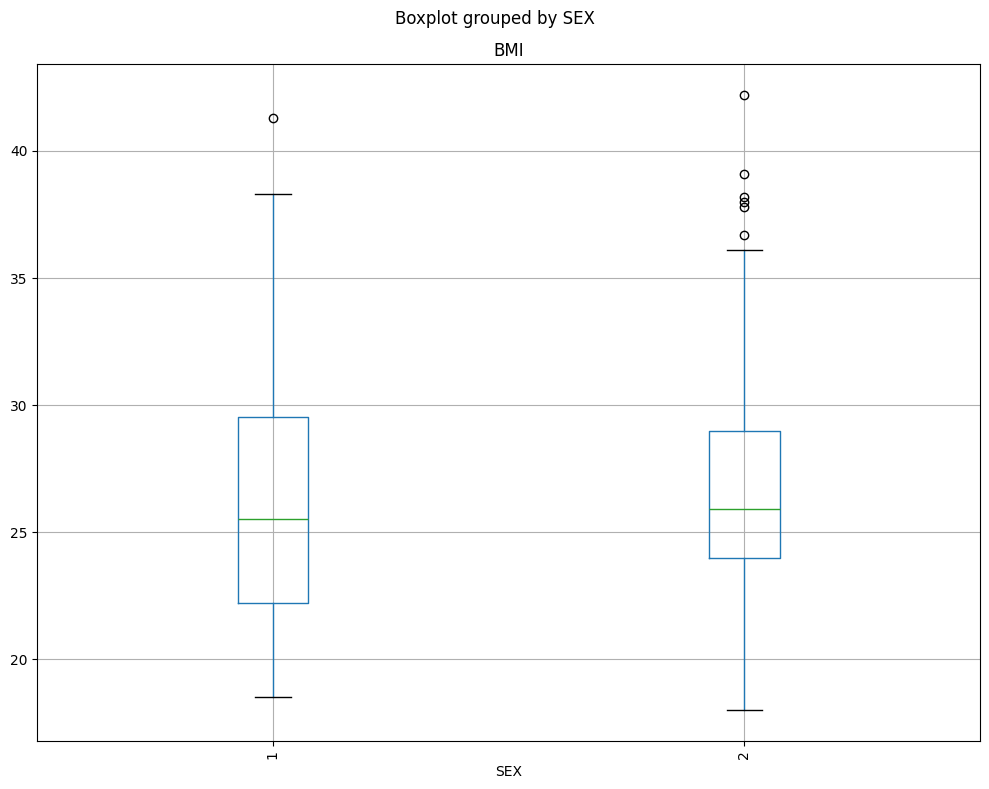

In [4]:
# Boxplot for BMI
df.boxplot(column='BMI', by='SEX', figsize=(10,8)) # Make a boxplot from column BMI and group by SEX using pandas boxplot
plt.xticks(rotation='vertical') # Rotate x-axis labels vertically
plt.tight_layout() # Adjust subplots to fit into figure area.
plt.show() # Display the plot

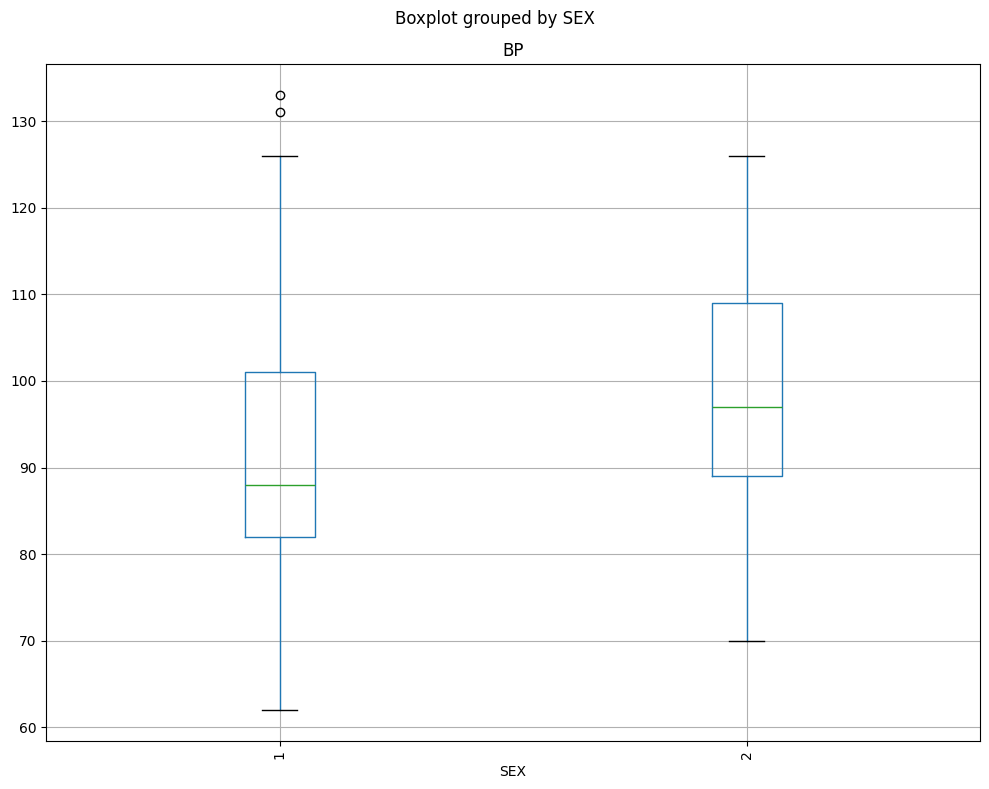

In [5]:
# Boxplot for Blood Pressure
df.boxplot(column='BP', by='SEX', figsize=(10,8)) # Make a boxplot from column BP and group by SEX using pandas boxplot
plt.xticks(rotation='vertical') # Rotate x-axis labels vertically
plt.tight_layout() # Adjust subplots to fit into figure area.
plt.show() # Display the plot

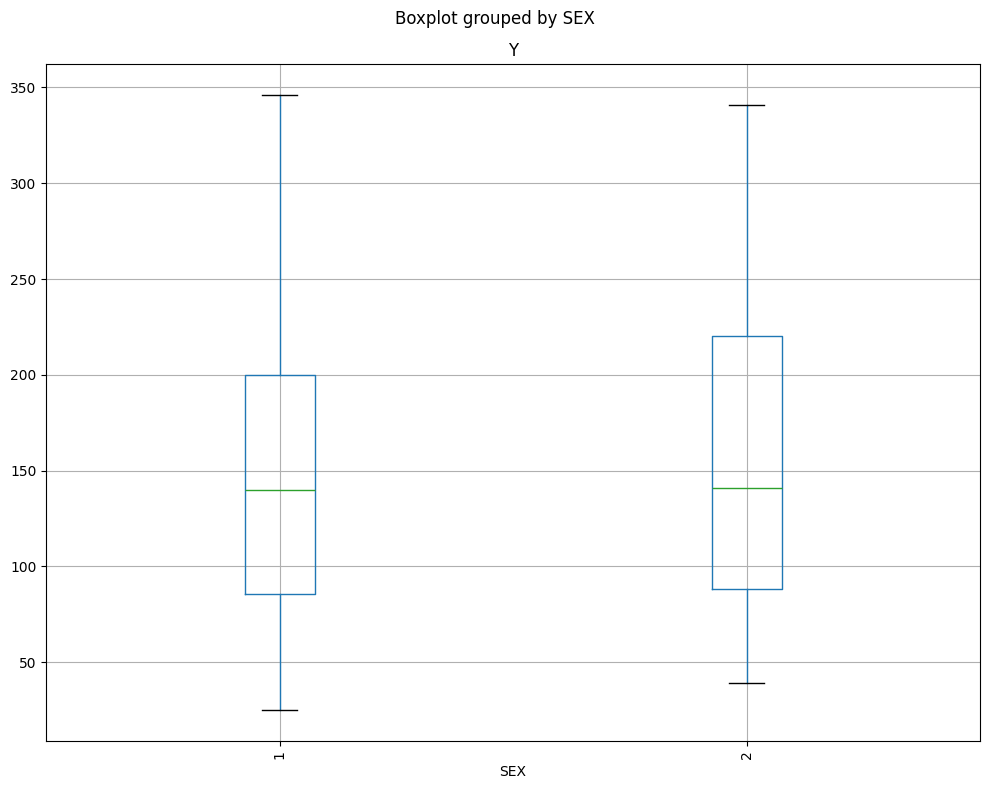

In [6]:
# Boxplot for Y
df.boxplot(column='Y', by='SEX', figsize=(10,8))
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

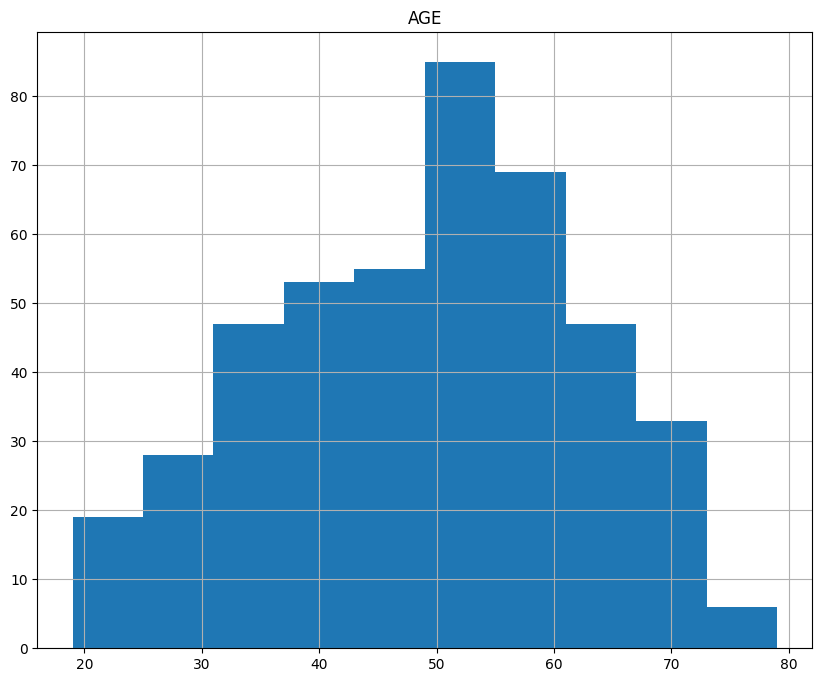

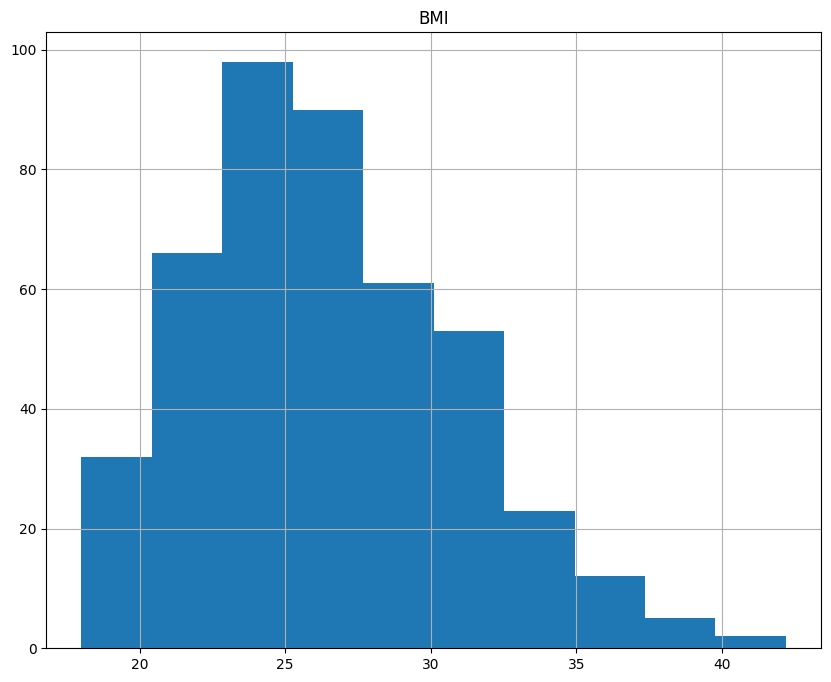

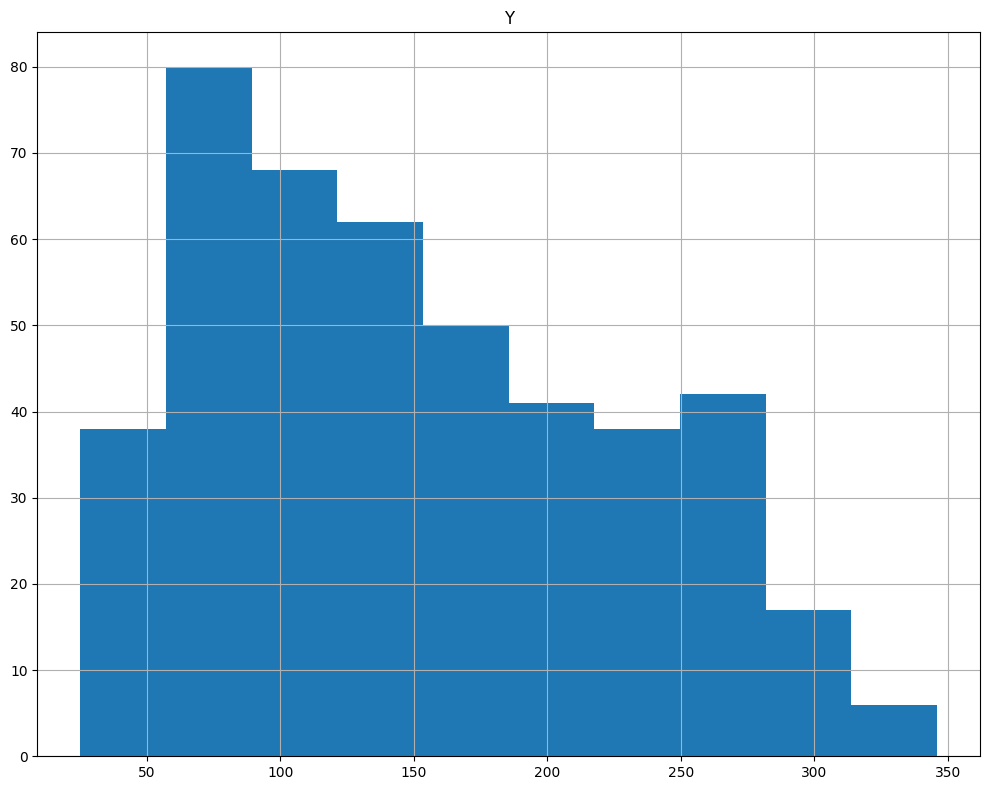

In [7]:
df.hist(column='AGE', figsize=(10,8)) # Histogram for AGE is normal distributed
df.hist(column='BMI', figsize=(10,8)) # Histogram for BMI is right skewed
df.hist(column='Y', figsize=(10,8)) # Histogram for BP is right skewed
plt.tight_layout() # Adjust subplots to fit into figure area.
plt.show() # Display the plots

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

In [8]:
# Make a columns list for correlation 
BMI = df['BMI']
BP = df['BP']
AGE = df['AGE']
Y = df['Y']

In [9]:
# Calculate covariance and correlation between BMI and Y
print(f'Covariance matrix between BMI and Y:\n{np.cov(BMI, Y)}\n')
print(f'Covariance between BP and Y:\n{np.cov(BMI, Y)[0,1]}\n')
print(f'Correlation coefficient between BP and Y:\n{np.corrcoef(BMI, Y)[0,1]}\n')

Covariance matrix between BMI and Y:
[[  19.51979812  199.74859021]
 [ 199.74859021 5943.33134792]]

Covariance between BP and Y:
199.74859020531292

Correlation coefficient between BP and Y:
0.5864501344746885



In [10]:
# Calculate covariance and correlation between BP and Y
print(f'Covariance matrix between BP and Y:\n{np.cov(BP, Y)}\n')
print(f'Covariance between BP and Y:\n{np.cov(BP,Y)[0,1]}\n')
print(f'Correlation between BP and Y:\n{np.corrcoef(BP,Y)[0,1]}\n')

Covariance matrix between BP and Y:
[[ 191.30440104  470.749878  ]
 [ 470.749878   5943.33134792]]

Covariance between BP and Y:
470.74987800248323

Correlation between BP and Y:
0.4414817585625713



In [11]:
# Calculate covariance and correlation between Age and Y
print(f'Covariance matrix between AGE and Y:\n{np.cov(AGE, Y)}\n')
print(f'Covariance between AGE and Y:\n{np.cov(AGE,Y)[0,1]}\n')
print(f'Correlation between AGE and Y:\n{np.corrcoef(AGE,Y)[0,1]}')

Covariance matrix between AGE and Y:
[[ 171.84661044  189.88306605]
 [ 189.88306605 5943.33134792]]

Covariance between AGE and Y:
189.8830660469316

Correlation between AGE and Y:
0.18788875071891978


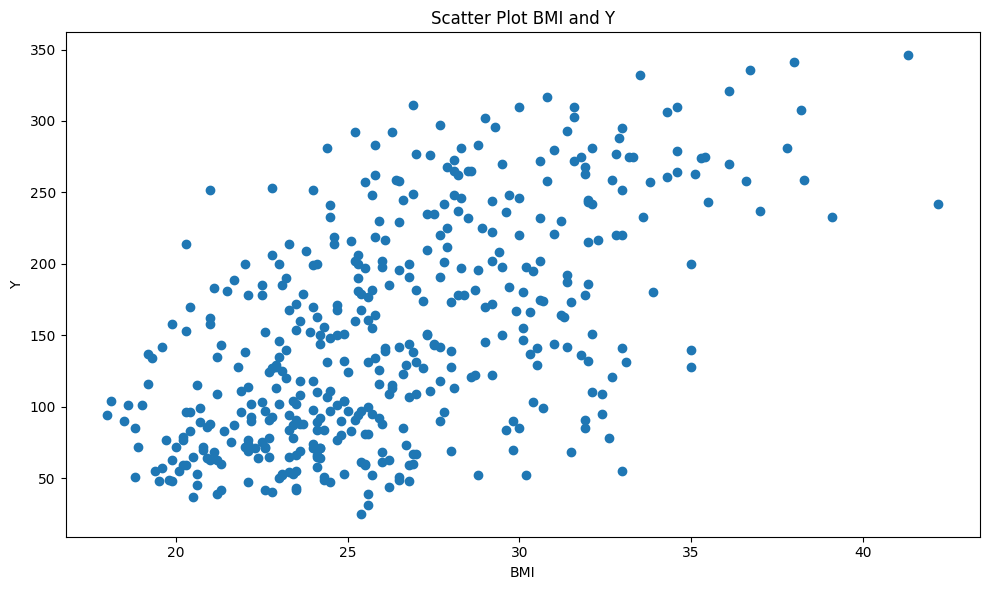

In [12]:
# Scatter plot for BMI and Y correlation
plt.figure(figsize=(10,6)) # Size for figure
plt.scatter(BMI,Y) # Scatter plot for BMI and Y
plt.title("Scatter Plot BMI and Y")
plt.xlabel("BMI")
plt.ylabel('Y')
plt.tight_layout()
plt.show()

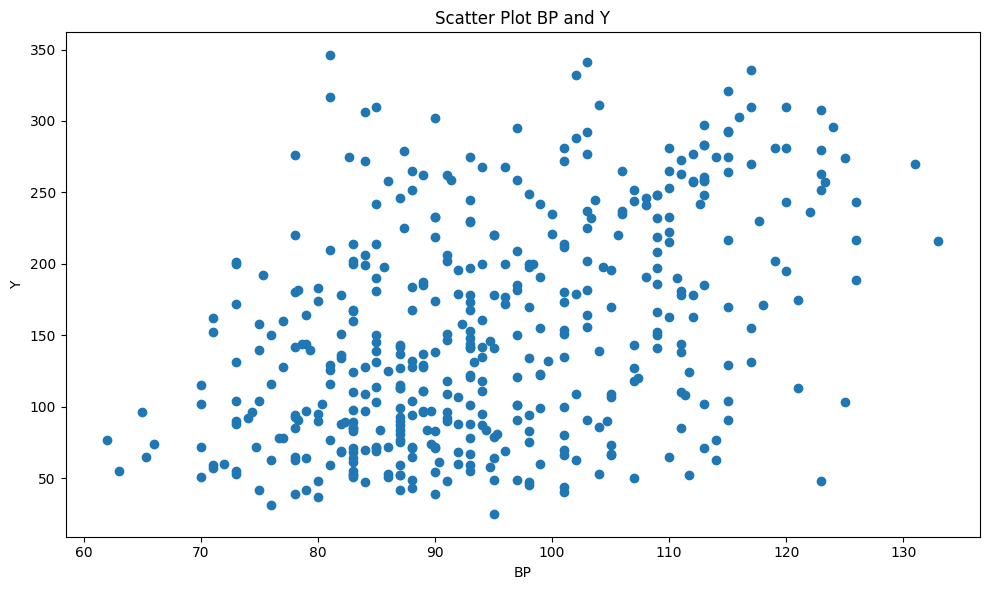

In [13]:
# Scatter plot for BP and Y correlation
plt.figure(figsize=(10,6)) # Size for figure
plt.scatter(BP,Y) # Scatter plot for BP and Y
plt.title("Scatter Plot BP and Y")
plt.xlabel("BP")
plt.ylabel('Y')
plt.tight_layout()
plt.show()

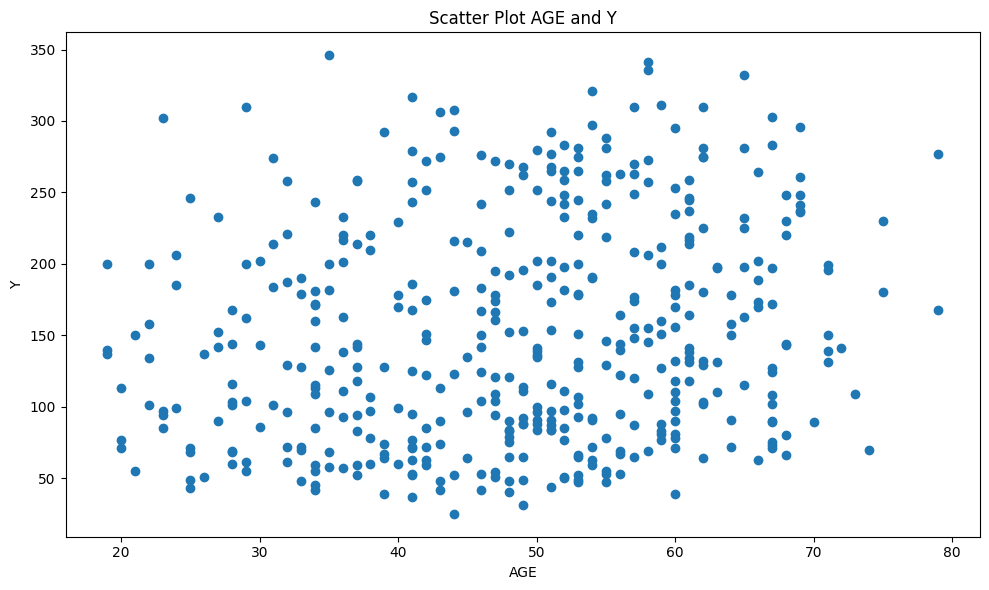

In [14]:
# Scatter plot for AGE and Y correlation
plt.figure(figsize=(10,6)) # Size for figure
plt.scatter(AGE,Y) # Scatter plot for BP and Y
plt.title("Scatter Plot AGE and Y")
plt.xlabel("AGE")
plt.ylabel('Y')
plt.tight_layout()
plt.show()

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

In [15]:
import scipy.stats

In [16]:
# This is function for search mean_confidence_interval
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h

In [17]:
# Compute mean confidence interval for BMI
for p in [0.85, 0.9, 0.95]:
    m, h = mean_confidence_interval(BMI,p)
    print(f"p={p:.2f}, mean confidence for BMI = {m:.2f} ± {h:.2f}")

p=0.85, mean confidence for BMI = 26.38 ± 0.30
p=0.90, mean confidence for BMI = 26.38 ± 0.35
p=0.95, mean confidence for BMI = 26.38 ± 0.41


In [18]:
# Compute mean confidence interval for BP
for p in [0.85, 0.9, 0.95]:
    m, h = mean_confidence_interval(BP,p)
    print(f"p={p:.2f}, mean for BP = {m:.2f} ± {h:.2f}")

p=0.85, mean for BP = 94.65 ± 0.95
p=0.90, mean for BP = 94.65 ± 1.08
p=0.95, mean for BP = 94.65 ± 1.29


In [19]:
# Compute mean confidence interval for AGE
for p in [0.85, 0.9, 0.95]:
    m, h = mean_confidence_interval(AGE,p)
    print(f"p={p:.2f}, mean confidence for AGE = {m:.2f} ± {h:.2f}")

p=0.85, mean confidence for AGE = 48.52 ± 0.90
p=0.90, mean confidence for AGE = 48.52 ± 1.03
p=0.95, mean confidence for AGE = 48.52 ± 1.23


In [20]:
# Group BMI, BP, AGE by SEX in mean 
df.groupby('SEX').agg({'BMI':'mean', 'BP':'mean', 'AGE':'mean'})

,BMI,BP,AGE
SEX,,,
1,26.010638,91.521957,46.382979
2,26.790338,98.194783,50.942029


In [21]:
# Mean Confidence interval for BMI by SEX
print('Mean Confidence interval for BMI group by sex')
for p in [0.85, 0.9, 0.95]:
    m1,h1 = mean_confidence_interval(df.loc[df['SEX']==1,['BMI']],p)
    m2,h2 = mean_confidence_interval(df.loc[df['SEX']==2,['BMI']],p)
    print(f'Conf={p:.2f}, Sex 1: {m1-h1[0]:.2f}..{m1+h1[0]:.2f}, Sex 2: {m2-h2[0]:.2f}..{m2+h2[0]:.2f}')

Mean Confidence interval for BMI group by sex
Conf=0.85, Sex 1: 25.58..26.44, Sex 2: 26.37..27.21
Conf=0.90, Sex 1: 25.52..26.50, Sex 2: 26.31..27.27
Conf=0.95, Sex 1: 25.42..26.60, Sex 2: 26.21..27.37


In [22]:
# Mean Confidence interval for BP by SEX
print('Mean Confidence interval for BP group by sex')
for p in [0.85, 0.9, 0.95]:
    m1,h1 = mean_confidence_interval(df.loc[df['SEX']==1,['BP']],p)
    m2,h2 = mean_confidence_interval(df.loc[df['SEX']==2,['BP']],p)
    print(f'Conf={p:.2f}, Sex 1: {m1-h1[0]:.2f}..{m1+h1[0]:.2f}, Sex 2: {m2-h2[0]:.2f}..{m2+h2[0]:.2f}')

Mean Confidence interval for BP group by sex
Conf=0.85, Sex 1: 90.19..92.85, Sex 2: 96.93..99.46
Conf=0.90, Sex 1: 90.00..93.04, Sex 2: 96.75..99.64
Conf=0.95, Sex 1: 89.71..93.34, Sex 2: 96.47..99.92


In [23]:
# Mean Confidence interval for AGE by SEX
print('Mean Confidence interval for AGE group by sex')
for p in [0.85, 0.9, 0.95]:
    m1,h1 = mean_confidence_interval(df.loc[df['SEX']==1,['AGE']],p)
    m2,h2 = mean_confidence_interval(df.loc[df['SEX']==2,['AGE']],p)
    print(f'Conf={p:.2f}, Sex 1: {m1-h1[0]:.2f}..{m1+h1[0]:.2f}, Sex 2: {m2-h2[0]:.2f}..{m2+h2[0]:.2f}')

Mean Confidence interval for AGE group by sex
Conf=0.85, Sex 1: 45.15..47.62, Sex 2: 49.67..52.22
Conf=0.90, Sex 1: 44.97..47.80, Sex 2: 49.48..52.40
Conf=0.95, Sex 1: 44.70..48.07, Sex 2: 49.20..52.68


In [24]:
# import for t test from library scipy
from scipy.stats import ttest_ind   

In [26]:
# T test for BMI
tval_BMI, pval_BMI = ttest_ind(df.loc[df['SEX']==1,['BMI']],df.loc[df['SEX']==2,['BMI']],equal_var=False)
print(f"T-value = {tval_BMI[0]:.2f}\nP-value: {pval_BMI[0]}")

T-value = -1.87
P-value: 0.06267725120660174


In [27]:
# T test for BP
tval_BP, pval_BP = ttest_ind(df.loc[df['SEX']==1,['BP']],df.loc[df['SEX']==2,['BP']],equal_var=False)
print(f"T-value = {tval_BP[0]:.2f}\nP-value: {pval_BP[0]}")

T-value = -5.25
P-value: 2.4156344804333644e-07


In [29]:
# T test for AGE
tval_AGE, pval_AGE = ttest_ind(df.loc[df['SEX']==1,['AGE']],df.loc[df['SEX']==2,['AGE']],equal_var=False)
print(f"T-value = {tval_AGE[0]:.2f}\nP-value: {pval_AGE[0]}")

T-value = -3.71
P-value: 0.00023555236507108289
